# Kasus 1 – Fase Feromagnetik (T = 1.0)

## Tujuan

Tujuan simulasi ini adalah mengimplementasikan algoritma Metropolis pada Model Ising dua dimensi untuk mengamati perilaku sistem pada temperatur rendah (T = 1.0), yaitu di bawah temperatur kritis (Tc ≈ 2,27). Simulasi dilakukan menggunakan kisi berukuran 20 × 20 dengan konfigurasi awal acak (Hot Start) dan dijalankan selama minimal 200.000 langkah Monte Carlo.

Melalui simulasi ini diharapkan dapat diamati proses terbentuknya fase feromagnetik, yaitu keadaan ketika spin-spin dalam sistem secara spontan cenderung berorientasi searah sehingga membentuk domain-domain magnetik yang besar. Selain itu, simulasi bertujuan untuk menganalisis perubahan magnetisasi rata-rata terhadap waktu serta memvisualisasikan konfigurasi akhir kisi spin menggunakan peta warna biner (`cmap='binary'`).

Hasil simulasi kemudian dianalisis berdasarkan konsep mekanika statistik untuk menunjukkan bahwa pada temperatur rendah interaksi antar-spin lebih dominan dibandingkan energi termal sehingga sistem memiliki magnetisasi yang tinggi dengan nilai |M| mendekati 1.

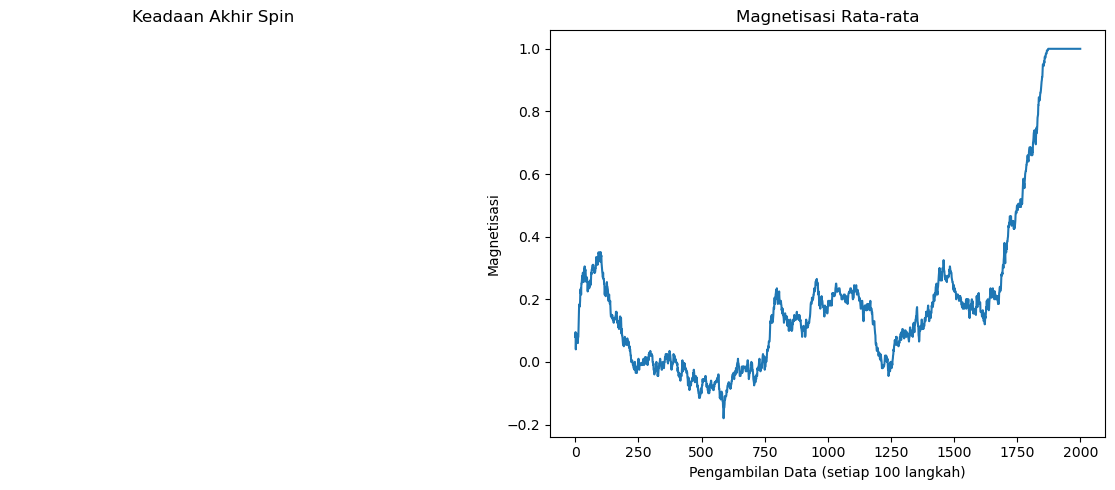

In [2]:
import numpy as np
import matplotlib.pyplot as plt
# ==============================
# PARAMETER SIMULASI
# ==============================

N = 20                 # Ukuran kisi 20 x 20
T = 1.0                # Temperatur (Fase Feromagnetik)
J = 1                  # Konstanta interaksi
MC_steps = 200000      # Jumlah Monte Carlo Step
interval = 100         # Interval penyimpanan magnetisasi
# ==============================
# HOT START
# ==============================

# Spin dipilih secara acak (-1 atau +1)

spin = np.random.choice([-1, 1], size=(N, N))
# ==============================
# FUNGSI DELTA ENERGI
# ==============================

def delta_energy(lattice, i, j):

    s = lattice[i, j]

    neighbors = (
        lattice[(i + 1) % N, j] +
        lattice[(i - 1) % N, j] +
        lattice[i, (j + 1) % N] +
        lattice[i, (j - 1) % N]
    )

    dE = 2 * J * s * neighbors

    return dE
# ==============================
# ALGORITMA METROPOLIS
# ==============================

magnetisasi = []

for step in range(MC_steps):

    # Memilih spin secara acak
    i = np.random.randint(0, N)
    j = np.random.randint(0, N)

    # Menghitung perubahan energi
    dE = delta_energy(spin, i, j)

    # Aturan Metropolis
    if dE <= 0:
        spin[i, j] *= -1

    else:
        if np.random.rand() < np.exp(-dE / T):
            spin[i, j] *= -1

    # Menyimpan magnetisasi setiap 100 langkah
    if step % interval == 0:
        M = np.sum(spin) / (N * N)
        magnetisasi.append(M)
# ==============================
# VISUALISASI
# ==============================

plt.figure(figsize=(12,5))

# Keadaan akhir spin
plt.subplot(1,2,1)
plt.imshow(spin, cmap='binary')
plt.title("Keadaan Akhir Spin")
plt.axis("off")

# Grafik magnetisasi
plt.subplot(1,2,2)
plt.plot(magnetisasi)
plt.title("Magnetisasi Rata-rata")
plt.xlabel("Pengambilan Data (setiap 100 langkah)")
plt.ylabel("Magnetisasi")

plt.tight_layout()
plt.show()

# Analisis Kasus 1 (T = 1.0)

Simulasi dilakukan pada temperatur T = 1.0 yang berada di bawah temperatur kritis (Tc ≈ 2,27). Pada kondisi ini energi interaksi antar-spin lebih dominan dibandingkan energi termal sehingga spin cenderung sejajar dengan spin tetangganya.

Selama simulasi menggunakan algoritma Metropolis, konfigurasi spin yang awalnya acak (Hot Start) secara bertahap berubah menjadi domain-domain besar dengan orientasi yang sama. Setelah mencapai kesetimbangan termal, hampir seluruh spin memiliki arah yang seragam sehingga terbentuk fase feromagnetik.

Grafik magnetisasi menunjukkan bahwa nilai magnetisasi rata-rata mendekati +1 atau −1. Nilai tersebut menandakan bahwa sistem telah mencapai keteraturan global. Visualisasi kisi spin juga memperlihatkan sebagian besar area memiliki warna yang sama, menunjukkan terbentuknya domain magnetik yang besar.

Hasil ini sesuai dengan teori Model Ising, yaitu pada temperatur rendah sistem berada pada fase feromagnetik dengan magnetisasi tinggi dan keteraturan spin yang kuat.